<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/Module2Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 2. Аналітика клієнтських даних і прогнозування відтоку (Telco Customer Churn)**

**Indian Telecom Customer Churn Dataset** — це набір даних для задач **прогнозування відтоку клієнтів (churn prediction)** та побудови **стратегій утримання (retention strategies)** у контексті індійського телеком-ринку. Він містить **10 000+ записів** (реалістично змодельованих “під реальний світ”) про клієнтів: їх **демографію**, **поведінку користування послугами**, **тарифні/підписні параметри**, а також **платіжні та витратні характеристики**.

https://www.kaggle.com/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset

## Структура файлів (5 CSV)

Набір включає кілька версій даних, що відображають типову логіку підготовки даних: **сирі дані -> очищення/обробка -> навчальний датасет**.

1. **`indian_customers_for_training.csv`**
   *Розмічений тренувальний набір* із **цільовою змінною** та **19 ознаками** для навчання моделей машинного навчання.

2. **`indian_customers_original.csv`**
   *Сирі дані до препроцесингу.* Дані **10 000 клієнтів**. Використовується для повного циклу підготовки: обробка пропусків, перетворення категорій, перевірки якості.

3. **`indian_customers_training.csv`**
   *Очищений та оброблений training-ready набір.* У ньому вже зменшено шум, виправлено типи, стандартизовано значення категорій та підготовлено дані до моделювання. Можна використовувати для порівняння із підготовленим самостійно набором даних.

4. **`indian_telecom_customers.csv`**
   *Повний файл з усіма записами клієнтів і всіма доступними ознаками.* Може слугувати “основною таблицею” для EDA, інженерії ознак та побудови різних варіантів вибірок. Можна використовувати для порівняння із підготовленим самостійно набором даних.

5. **`subscription_data.csv`**
   *Історичні дані підписки та білінгу* для **10 000 клієнтів**. Це важливий компонент для сценаріїв, де потрібно:

   * агрегувати історію по клієнту (середні/суми/тенденції),
   * будувати “поведінкові” ознаки,
   * поєднувати основний профіль клієнта з фінансовою історією.


**В наборі даних є декілька таблиць даних з різним рівнем обробки даних. Необхідно проаналізувати зміст цих таблиць та вирішити з якою з них працювати далі.**


## Ознаки (Features / Columns): що саме описують

### Демографія

Цей блок описує “хто клієнт” і його контекст:

* **Age** — вік (може корелювати зі стилем споживання та лояльністю).
* **Gender** — стать (часто потребує коректної обробки як категорії).
* **City** — місто (просторові/соціально-економічні відмінності можуть впливати на churn).
* **Dependents** — наявність утриманців/залежних (побічно може впливати на стабільність підписки).
* **Profession** — професія/сфера зайнятості (зазвичай категоріальна ознака з кількома класами).

### Послуги та використання (Services & Usage)

Цей блок описує “як клієнт користується сервісом” і наскільки він “вбудований” у оператора:

* **Telecom Operator** — оператор зв’язку: **Airtel, Jio, Vi, BSNL**.
  Це важлива категорійна ознака, бо політики тарифів/якість мережі/покриття можуть бути різними.
* **Plan Type** — тип плану: **Prepaid / Postpaid**.
  Часто суттєво впливає на churn: prepaid зазвичай легше змінюють, postpaid можуть мати інші патерни.
* **Tenure** — тривалість користування (місяці з оператором).
  Це одна з найсильніших ознак у churn-задачах: короткий tenure часто означає підвищений ризик.
* **Customer Support Calls** — кількість звернень до підтримки.
  Високе значення може бути сигналом проблем (якість зв’язку/рахунки/сервіс) і зростання ризику churn.
* **Usage Patterns / Usage Patterns** — узагальнений блок/колонки про патерни споживання (інтенсивність, частота тощо).
  У реальних задачах сюди відносять дзвінки, SMS, data usage, пікові навантаження — і це майже завжди ключові предиктори.

### Білінг та платежі (Billing)

Фінансовий блок описує “скільки і як платить клієнт”:

* **Monthly Charges** — щомісячні нарахування.
* **Total Spend** — сукупні витрати за період (часто пов’язані з tenure, тож важливо уникати некоректних інтерпретацій).
* **Payment Method** — метод оплати: **UPI, Net Banking, Credit Card, Wallet**.


## Цільова змінна (Target)

* **Churn (Yes/No)** — чи відмовився клієнт від послуг оператора.
  Це **бінарна класифікація**, де зазвичай важливі не тільки accuracy, а й **recall/precision для класу “Yes”**, оскільки саме “відтік” часто є меншою часткою і бізнесово значущим.




## План аналізу

1. **Групування даних**.

2. **Інженерія ознак** і перетворення.

3. **EDA** та візуалізації.





#**Групування даних**

**Мета** — отримати **надійний** і **зрозумілий** датафрейм на рівні клієнта (1 рядок = 1 клієнт), з правильно сформованою цільовою ознакою відтоку та перевіреною якістю злиття. Валідація `merge` (кардинальність/унікальність/очікувані розміри) захищає від помилок, а базові перевірки, статистики, викиди та робота з пропусками роблять подальші висновки стабільними.

**План**
1. Завантаження та огляд структури даних.
2. Перетворення типів і базова нормалізація категорій (наприклад, Yes/No), формування цільової ознаки відтоку.
3. Агрегації та підготовка проміжних таблиць за необхідності.
4. Об’єднання таблиць у один customer-level датафрейм за необхідності.
5. Перевірка якості (shape/dtypes/missing/duplicates), базові статистики, виявлення викидів та заповнення пропусків.

**Результат заняття:** підготовлений customer-level датафрейм (наприклад, `df_customer_imp`), готовий для інженерії ознак і подальшого аналізу.







Підключення бібліотек для завантаження даних з Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kiranmehta1/indian-telecom-customer-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.92M/1.92M [00:00<00:00, 37.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re

import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option("display.max_columns", 200)   # або None — без обмеження
pd.set_option("display.width", 140)         # ширина рядка у символах
pd.set_option("display.max_colwidth", 50)   # ширина вмісту комірки (None — без обрізання)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/subscription_data.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_training.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_original.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_for_training.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_telecom_customers.csv


# Завантаження даних

Завантаження таблиць даних та базові перевірки

In [ ]:
path = "/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/"

paths = {
    "indian_customers_original":      path + "indian_customers_original.csv",
    "indian_telecom_customers":       path + "indian_telecom_customers.csv",
    "indian_customers_for_training":  path + "indian_customers_for_training.csv",
    "indian_customers_training":      path + "indian_customers_training.csv",
    "subscription_data":              path + "subscription_data.csv",
}

dfs = {name: pd.read_csv(path) for name, path in paths.items()}

# Швидка перевірка розмірів
pd.DataFrame({k: {"rows": v.shape[0], "cols": v.shape[1]} for k, v in dfs.items()}).T




,rows,cols
indian_customers_original,10000,39
indian_telecom_customers,15000,39
indian_customers_for_training,10000,20
indian_customers_training,15000,20
subscription_data,10000,11


In [ ]:
dfs.keys()

dict_keys(['indian_customers_original', 'indian_telecom_customers', 'indian_customers_for_training', 'indian_customers_training', 'subscription_data'])

In [ ]:
print("customer data original:", dfs['indian_customers_original'].shape)

display(dfs['indian_customers_original'])
display(dfs['indian_customers_original'].info())


customer data original: (10000, 39)


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 10000 non-null  object 
 1   name                        10000 non-null  object 
 2   phone                       10000 non-null  int64  
 3   gender                      10000 non-null  object 
 4   age                         10000 non-null  int64  
 5   city                        10000 non-null  object 
 6   state                       10000 non-null  object 
 7   pincode                     10000 non-null  int64  
 8   city_tier                   10000 non-null  object 
 9   profession                  10000 non-null  object 
 10  annual_income_lakhs         10000 non-null  float64
 11  is_married                  10000 non-null  bool   
 12  has_children                10000 non-null  bool   
 13  num_dependents              1000

None

In [ ]:
print("customer all data :", dfs['indian_telecom_customers'].shape)

display(dfs['indian_telecom_customers'])
display(dfs['indian_telecom_customers'].info())


customer all data : (15000, 39)


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,IND014996,Ananya Nair,919187844900,Female,25,Lucknow,Uttar Pradesh,557443,Tier 1,Business Owner,39.83,False,False,0,Airtel,Premium,745,True,24,17880,10,73,30,True,False,UPI,0,Bengali,False,2,5,1,9,3,10,False,False,0.551,No
14996,IND014997,Chitra Shah,918077266399,Female,21,Delhi,Delhi,652873,Tier 1,Farmer,14.01,False,False,0,Vi,Standard,500,True,45,22500,32,91,18,True,True,Net Banking,1,English,False,1,3,2,2,2,6,False,False,0.617,No
14997,IND014998,Sachin Arora,919955444155,Male,33,Aligarh,Maharashtra,162678,Tier 3,Student,3.35,False,False,0,Jio,Basic,143,True,28,4004,47,266,62,True,True,Net Banking,0,English,False,0,4,2,10,1,9,False,False,0.652,Yes
14998,IND014999,Neha Ghosh,918050607459,Female,33,Vadodara,Maharashtra,311495,Tier 2,IT Professional,16.90,False,False,0,Jio,Premium,906,True,5,4530,53,382,52,True,True,Net Banking,1,Tamil,True,1,1,6,6,5,7,False,False,0.728,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  object 
 1   name                        15000 non-null  object 
 2   phone                       15000 non-null  int64  
 3   gender                      15000 non-null  object 
 4   age                         15000 non-null  int64  
 5   city                        15000 non-null  object 
 6   state                       15000 non-null  object 
 7   pincode                     15000 non-null  int64  
 8   city_tier                   15000 non-null  object 
 9   profession                  15000 non-null  object 
 10  annual_income_lakhs         15000 non-null  float64
 11  is_married                  15000 non-null  bool   
 12  has_children                15000 non-null  bool   
 13  num_dependents              150

None

In [ ]:
print("customer data for ML training:", dfs['indian_customers_for_training'].shape)

display(dfs['indian_customers_for_training'])
display(dfs['indian_customers_for_training'].info())


customer data for ML training: (10000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,0,Yes,Yes,32,282,9024,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Electronic check,Yes
1,Female,0,Yes,Yes,27,322,8694,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),Yes
2,Male,0,No,No,2,504,1008,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Credit card (automatic),Yes
3,Female,0,Yes,Yes,7,882,6174,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
4,Male,0,No,No,7,421,2947,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,0,No,Yes,1,593,593,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),No
9996,Female,0,Yes,Yes,11,896,9856,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
9997,Female,0,No,No,15,181,2715,Yes,No,No,No,No,No,No,No,No,One year,Yes,Electronic check,No
9998,Female,0,Yes,Yes,20,125,2500,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            10000 non-null  object
 1   SeniorCitizen     10000 non-null  int64 
 2   Partner           10000 non-null  object
 3   Dependents        10000 non-null  object
 4   tenure            10000 non-null  int64 
 5   MonthlyCharges    10000 non-null  int64 
 6   TotalCharges      10000 non-null  int64 
 7   PhoneService      10000 non-null  object
 8   MultipleLines     10000 non-null  object
 9   InternetService   10000 non-null  object
 10  OnlineSecurity    10000 non-null  object
 11  OnlineBackup      10000 non-null  object
 12  DeviceProtection  10000 non-null  object
 13  TechSupport       10000 non-null  object
 14  StreamingTV       10000 non-null  object
 15  StreamingMovies   10000 non-null  object
 16  Contract          10000 non-null  object
 17  PaperlessBill

None

In [ ]:
print("customer data, cleaned and preprocessed:", dfs['indian_customers_training'].shape)

display(dfs['indian_customers_training'])
display(dfs['indian_customers_training'].info())


customer data, cleaned and preprocessed: (15000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,0,Yes,Yes,32,282,9024,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Electronic check,Yes
1,Female,0,Yes,Yes,27,322,8694,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),Yes
2,Male,0,No,No,2,504,1008,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,No,Credit card (automatic),Yes
3,Female,0,Yes,Yes,7,882,6174,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
4,Male,0,No,No,7,421,2947,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Female,0,No,No,24,745,17880,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Electronic check,No
14996,Female,0,No,No,45,500,22500,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),No
14997,Male,0,No,No,28,143,4004,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),Yes
14998,Female,0,No,No,5,906,4530,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            15000 non-null  object
 1   SeniorCitizen     15000 non-null  int64 
 2   Partner           15000 non-null  object
 3   Dependents        15000 non-null  object
 4   tenure            15000 non-null  int64 
 5   MonthlyCharges    15000 non-null  int64 
 6   TotalCharges      15000 non-null  int64 
 7   PhoneService      15000 non-null  object
 8   MultipleLines     15000 non-null  object
 9   InternetService   15000 non-null  object
 10  OnlineSecurity    15000 non-null  object
 11  OnlineBackup      15000 non-null  object
 12  DeviceProtection  15000 non-null  object
 13  TechSupport       15000 non-null  object
 14  StreamingTV       15000 non-null  object
 15  StreamingMovies   15000 non-null  object
 16  Contract          15000 non-null  object
 17  PaperlessBil

None

In [ ]:
print("Subscription data:", dfs['subscription_data'].shape)

display(dfs['subscription_data'])
display(dfs['subscription_data'].info())


Subscription data: (10000, 11)


,SubscriptionID,CustomerID,CustomerName,Email,City,PlanType,Amount,StartDate,EndDate,Status,PaymentMethod
0,SUB-100000,CUST-29478,Vikram Kulkarni,vikram.kulkarni@example.com,Delhi,Standard,499,2023-06-16,2023-07-16,Active,UPI
1,SUB-100001,CUST-41541,Kiara Malhotra,kiara.malhotra@example.com,Visakhapatnam,Standard,499,2023-04-05,2023-07-04,Active,Wallet
2,SUB-100002,CUST-91250,Arjun Nair,arjun.nair@example.com,Chennai,Basic,199,2023-07-16,2023-10-14,Pending,Net Banking
3,SUB-100003,CUST-71590,Reyansh Saxena,reyansh.saxena@example.com,Bangalore,Enterprise,4999,2023-07-08,2023-10-06,Active,Net Banking
4,SUB-100004,CUST-36595,Neha Reddy,neha.reddy@example.com,Nagpur,Basic,199,2023-08-31,2023-11-29,Expired,UPI
...,...,...,...,...,...,...,...,...,...,...,...
9995,SUB-109995,CUST-88258,Pooja Singh,pooja.singh@example.com,Vadodara,Premium,999,2023-01-30,2024-01-30,Active,Debit Card
9996,SUB-109996,CUST-55353,Aadhya Patel,aadhya.patel@example.com,Pune,Standard,499,2023-07-22,2023-08-21,Active,Net Banking
9997,SUB-109997,CUST-78709,Ananya Kapoor,ananya.kapoor@example.com,Jaipur,Basic,199,2023-07-13,2023-10-11,Active,UPI
9998,SUB-109998,CUST-26330,Vihaan Jain,vihaan.jain@example.com,Indore,Basic,199,2023-07-26,2023-10-24,Active,Wallet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SubscriptionID  10000 non-null  object
 1   CustomerID      10000 non-null  object
 2   CustomerName    10000 non-null  object
 3   Email           10000 non-null  object
 4   City            10000 non-null  object
 5   PlanType        10000 non-null  object
 6   Amount          10000 non-null  int64 
 7   StartDate       10000 non-null  object
 8   EndDate         10000 non-null  object
 9   Status          10000 non-null  object
 10  PaymentMethod   10000 non-null  object
dtypes: int64(1), object(10)
memory usage: 859.5+ KB


None

# Базовий профіль таблиць: розмір, пропуски, дублі, типи

Цей блок дає “паспорт” кожної таблиці:
- кількість рядків/стовпців
- кількість повних дублікатів рядків
- кількість пропусків (в ідеалі 0)
- пам’ять (MB)
- скільки числових / текстових / булевих ознак

In [ ]:
# Функція візуалізації таблиці з характеристиками

,n_rows,n_cols,dup_rows,dup_rows_%,missing_cells,missing_cols,n_numeric,n_object,n_bool
indian_customers_for_training,10000.0,20.0,4.0,0.040000,0.0,0.0,4.0,16.0,0.0
indian_customers_original,10000.0,39.0,0.0,0.000000,0.0,0.0,19.0,12.0,8.0
indian_customers_training,15000.0,20.0,10.0,0.066667,0.0,0.0,4.0,16.0,0.0
indian_telecom_customers,15000.0,39.0,0.0,0.000000,0.0,0.0,19.0,12.0,8.0
subscription_data,10000.0,11.0,0.0,0.000000,0.0,0.0,1.0,10.0,0.0


## Порівняння схем (наборів колонок)

Порівняння таблиць на рівні структури:
- чи однаковий набір колонок у `indian_customers_original` та `indian_telecom_customers`
- чи співпадає схема у двох “training” таблиць
- чи є ознаки, що відсутні/додані між файлами



In [ ]:
# Функція порівняння наборів ознак в різних таблицях

Отже, за структурою таблиці з парними назвами схожі.

## Описова статистика

### Числові ознаки
Показуємо `mean/std/min/квартилі/max` для числових колонок.

### Булеві ознаки
Для булевих колонок доцільно дивитись частку `True` (середнє значення).

### Категоріальні ознаки
Для категорійних — кількість унікальних значень та топ-значення з частотами.

In [ ]:
# Функції описової статистики для порівняння таблиць даних

## Перевірка customer_id / CustomerID та перетин клієнтів

Завдання:
1) визначити, у яких таблицях є колонка ідентифікатора клієнта (`customer_id` або `CustomerID`);
2) перевірити унікальність ID в кожній таблиці;
3) обчислити **перетин** множин клієнтів між таблицями:
- Intersection size
- Coverage A→B (яка частка клієнтів A присутня в B)
- Coverage B→A
- Jaccard (|A∩B| / |A∪B|)

In [ ]:
# Функції перевірки customer_id / CustomerID та перетину клієнтів

## Додатково: “training” таблиці — чи це ті самі записи?

У `indian_customers_for_training` та `indian_customers_training` немає customer_id, тому перетин клієнтів обчислити напряму неможливо.
Однак можна перевірити **перетин рядків** (однакові комбінації ознак).
Це відповідає питанню: “чи training-набір — це надмножина smaller training, чи це інша генерація/вибірка?”

In [ ]:
# Код перевірки

Обрати саме **`df_original` (`indian_customers_original.csv`)** для подальшого аналізу доречніше у порівнянні із *_train* наборами.

`df_original` позиціонується як **raw до preprocessing** в описі набору даних. Це важливо, бо саме на цьому етапі коректно:

* виявляти пропуски, неузгоджені категорії, аномальні значення;
* приймати рішення про обробку (impute, фільтрація, нормалізація значень, кодування);

Якщо почати з уже “cleaned/training-ready”, частина проблем уже прихована або виправлена, отже, не видно оригінального стану та немає можливості впливати на результат.

У `df_original` є `customer_id`, тобто можна робити customer-level аналіз і контроль унікальності

`df_original` має повнішу “бізнесову картину”, ніж training-таблиці

Training-файли зазвичай містять лише ті ознаки, які автор набору даних вважає потрібними для моделі (і часто вже в перетвореному вигляді).

`df_original` (39 колонок у твоєму файлі) містить ширший контекст: демографію, поведінку, сервісні прапорці, оцінки задоволеності, чутливість до ціни, сезонні фактори, тощо.

`df_original` узгоджений за схемою з `indian_telecom_customers`, тобто зручний як “базова” версія.

Отже, можна:

* почати аналіз на `df_original` (10k) як на меншому контрольному наборі;
* а потім масштабувати висновки/пайплайн за необхідності на `indian_telecom_customers` (15k) без зміни коду по колонках.



In [ ]:
df_customer = dfs['indian_customers_original']

###Перетворення “Yes/No” у зручний формат

Багато полів у services — це Yes/No. Для частини задач зручно мати 0/1.


In [ ]:
# Код перетворення для колонки churn

In [ ]:
# функції, що додають в ознаки інтерпретовані бінінги

# "tenure_bucket"

# "age_bucket"

# "income_q"

# "sat_bucket"

# "risk_decile"

# "delay_bucket_6m"

##**Агрегації таблиць даних**

Оскільки services і status — це вже **customer-level** таблиці (1 рядок = 1 клієнт), “підготовчі агрегації” тут більше стосуються довідників (наприклад, population) або побудови агрегованих зрізів.

Розглянемо далі два типових приклади:

1. **Zip Code → Population (усунення можливих дублікатів)** дає *коректний довідник* для приєднання: один `Zip Code` → одне значення `Population`. Це потрібно, щоб `merge()` не “розмножував” рядки клієнтів через дублікати ключа в `population`, і щоб чисельність населення була узгодженою ознакою (без випадкових розбіжностей для одного й того самого індексу).

2. **Зріз churn по Contract/Payment Method** дає *перші бізнес-інсайти* і *швидку перевірку даних*: видно, у яких типах контрактів або способах оплати відтік вищий/нижчий, чи є дисбаланс класів, чи не “зламані” категорії (наприклад, дивні значення, дуже рідкі групи). Такий `groupby` також підказує, які категоріальні поля можуть бути сильними факторами для моделі та сегментації.


In [ ]:
def churn_group_agg(df: pd.DataFrame, group_cols, min_n: int = 0) -> pd.DataFrame:
    overall = df["churn_flag"].mean()

    g = (
        df.groupby(group_cols, dropna=False, observed=True)
          .agg(
              customers=("customer_id", "size"),
              churn_cnt=("churn_flag", "sum"),
              churn_rate=("churn_flag", "mean"),
              tenure_mean=("tenure_months", "mean"),
              monthly_charges_mean=("monthly_charges", "mean"),
              total_charges_mean=("total_charges", "mean"),
              data_usage_gb_mean=("data_usage_gb", "mean"),
              voice_minutes_mean=("voice_minutes", "mean"),
              support_calls_mean=("support_calls_last_month", "mean"),
              satisfaction_mean=("overall_satisfaction", "mean"),
              delays_mean=("payment_delays_last_6m", "mean"),
          )
          .reset_index()
    )

    g["churn_rate_%"] = (g["churn_rate"] * 100).round(2)
    g["segment_share_%"] = (g["customers"] / len(df) * 100).round(2)
    g["lift_vs_overall"] = (g["churn_rate"] / overall).round(3)

    g = g.drop(columns=["churn_rate"])
    if min_n > 0:
        g = g[g["customers"] >= min_n].copy()

    return g.sort_values(["churn_rate_%", "customers"], ascending=[False, False])

# KPI по всій базі
kpi = pd.DataFrame([{
    "customers": len(df_customer),
    "churn_cnt": int(df_customer["churn_flag"].sum()),
    "churn_rate_%": round(df_customer["churn_flag"].mean() * 100, 2),
    "tenure_mean": round(df_customer["tenure_months"].mean(), 2),
    "monthly_charges_mean": round(df_customer["monthly_charges"].mean(), 2),
    "total_charges_mean": round(df_customer["total_charges"].mean(), 2),
    "support_calls_mean": round(df_customer["support_calls_last_month"].mean(), 3),
    "overall_satisfaction_mean": round(df_customer["overall_satisfaction"].mean(), 3),
    "payment_delays_mean_6m": round(df_customer["payment_delays_last_6m"].mean(), 3),
}])

# ключові зрізи (категоріальні)
agg_operator        = churn_group_agg(df_customer, ["operator"])
agg_plan_type       = churn_group_agg(df_customer, ["plan_type"])
agg_operator_plan   = churn_group_agg(df_customer, ["operator", "plan_type"])
agg_city_tier       = churn_group_agg(df_customer, ["city_tier"])
agg_payment_method  = churn_group_agg(df_customer, ["payment_method"])

# “service flags” (булеві, але вже придатні для групування)
agg_has_internet    = churn_group_agg(df_customer, ["has_internet"])
agg_has_ott_bundle  = churn_group_agg(df_customer, ["has_ott_bundle"])
agg_reg_support     = churn_group_agg(df_customer, ["prefers_regional_support"])
agg_is_prepaid      = churn_group_agg(df_customer, ["is_prepaid"])

# зрізи по бінінгах
agg_tenure_bucket   = churn_group_agg(df_customer, ["tenure_bucket"])
agg_age_bucket      = churn_group_agg(df_customer, ["age_bucket"])
agg_income_q        = churn_group_agg(df_customer, ["income_q"])
agg_sat_bucket      = churn_group_agg(df_customer, ["sat_bucket"])
agg_risk_decile     = churn_group_agg(df_customer, ["risk_decile"])
agg_delay_bucket    = churn_group_agg(df_customer, ["delay_bucket_6m"])

# локації
agg_state_min50     = churn_group_agg(df_customer, ["state"], min_n=50)
agg_city_min50      = churn_group_agg(df_customer, ["city"],  min_n=50)

# churn vs non-churn: порівняння числових ознак
num_cols = [
    "age","annual_income_lakhs","monthly_charges","tenure_months","total_charges",
    "data_usage_gb","voice_minutes","sms_count","support_calls_last_month",
    "network_satisfaction","price_satisfaction","overall_satisfaction",
    "payment_delays_last_6m","competitor_offers_received","price_sensitivity_score","churn_probability"
]
num_cols = [c for c in num_cols if c in df_customer.columns]

by_churn_mean = (
    df_customer.groupby("churn", observed=True)[num_cols]
    .mean()
    .T.rename(columns={"No":"mean_No", "Yes":"mean_Yes"})
)
by_churn_median = (
    df_customer.groupby("churn", observed=True)[num_cols]
    .median()
    .T.rename(columns={"No":"med_No", "Yes":"med_Yes"})
)

compare_num = by_churn_mean.join(by_churn_median)
compare_num["delta_mean(Yes-No)"] = (compare_num["mean_Yes"] - compare_num["mean_No"]).round(3)
compare_num["delta_med(Yes-No)"]  = (compare_num["med_Yes"]  - compare_num["med_No"]).round(3)
compare_num = compare_num.sort_values("delta_mean(Yes-No)", ascending=False)

# оператор × tenure
agg_operator_tenure = churn_group_agg(df_customer, ["operator", "tenure_bucket"])


In [ ]:
agg_operator_tenure

,operator,tenure_bucket,customers,churn_cnt,tenure_mean,monthly_charges_mean,total_charges_mean,data_usage_gb_mean,voice_minutes_mean,support_calls_mean,satisfaction_mean,delays_mean,churn_rate_%,segment_share_%,lift_vs_overall
20,Others,12-24,34,21,17.852941,579.323529,11111.411765,28.029412,263.323529,0.882353,6.029412,0.352941,61.76,0.34,1.256
24,Vi,0-6,796,482,3.076633,545.114322,1667.496231,30.413317,296.168342,0.781407,5.513819,0.503769,60.55,7.96,1.231
12,Jio,0-6,1127,674,2.937001,564.832298,1717.001775,28.928128,300.496007,0.793256,5.450754,0.504880,59.8,11.27,1.216
19,Others,6-12,29,17,8.413793,675.517241,5815.517241,21.034483,238.827586,0.655172,5.172414,0.310345,58.62,0.29,1.192
6,BSNL,0-6,255,149,3.007843,541.400000,1640.639216,30.435294,318.396078,0.792157,5.854902,0.486275,58.43,2.55,1.188
0,Airtel,0-6,916,534,2.923581,568.684498,1656.102620,30.026201,300.858079,0.822052,5.513100,0.500000,58.3,9.16,1.185
18,Others,0-6,58,33,2.534483,480.275862,1349.362069,31.017241,343.844828,0.775862,5.068966,0.344828,56.9,0.58,1.157
26,Vi,12-24,592,303,17.790541,575.222973,10271.954392,28.371622,304.146959,0.820946,5.570946,0.425676,51.18,5.92,1.041
22,Others,36-60,22,11,46.000000,379.181818,17280.590909,24.181818,235.863636,0.590909,6.045455,0.636364,50.0,0.22,1.016
13,Jio,6-12,672,330,9.348214,548.875000,5158.153274,29.446429,303.425595,0.828869,5.430060,0.488095,49.11,6.72,0.998


##**Об'єднання таблиць даних в один датафрейм**

Як і в першому модулі формування об'єднаної таблиці є важливим етапом для подальшого аналізу.

Об’єднання таблиць через `merge()` потрібне, щоб зібрати дані про один об’єкт в **єдину аналітичну таблицю** для метрик, ознак і порівнянь. Це поєднує різні частини інформації (статуси, локацію тощо) за ключами. Важливо контролювати гранулярність і за потреби попередньо агрегувати, щоб не отримати дублювання рядків і спотворення статистики.


###**Варіант A: Customer-level**

Концепція customer-level:  
**1 рядок = 1 клієнт**. Це основна таблиця для EDA/ML, бо містить і ціль (churn), і пояснювальні ознаки, і локацію/населення.


In [ ]:
df_customer



,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,24-36,36-45,Q1_low,low(1-3),D8,0
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,24-36,36-45,Q4_high,mid(4-7),D6,0
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6,18-25,Q1_low,high(8-10),D8,1
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,6-12,36-45,Q3,high(8-10),D6,0
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,6-12,26-35,Q2,high(8-10),D3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6,26-35,Q4_high,mid(4-7),D9,0
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,6-12,26-35,Q4_high,high(8-10),D5,0
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,12-24,26-35,Q2,high(8-10),D3,0
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No,0,12-24,26-35,Q2,high(8-10),D2,0


##**Базові перевірки розмірностей та типів даних**

- Shape: розмірність (важливо після merge).
- Dtypes: типи ознак (числові/категоріальні).
- Missing: частка пропусків (які колонки потребують уваги).
- Duplicates: чи є повні дублікати рядків (іноді виникають через merge).


In [ ]:
# Функція базових перевірок

##Обчислення базової статистики


Базова статистика (count/mean/median/std/квантілі/min/max) потрібна, щоб швидко відповісти на ключові питання:

* які типові значення ознак (середнє/медіана),
* чи є “дивні” значення (min/max),
* чи великий розкид (std, IQR),
* чи є ознаки з великою часткою нулів/пропусків.


Нагадаємо, що до  основних статистик відноситься:

* count — кількість непорожніх значень,
* mean/median — центральна тенденція,
* std — варіативність,
* min/max — крайні значення,
* 25%/50%/75% — квартилі.

Більш детально ці статистики були розглянуті у модулі 1.

In [ ]:
# Функції обчислення базових статистик

##**Виявлення викидів даних**

Визначимо викиди за правилом **IQR**: значення нижче Q1 − 1.5·IQR або вище Q3 + 1.5·IQR.

Це не “погані” дані автоматично, але сигнал:
* перевірити коректність,
* зрозуміти сегменти,
* вирішити, чи потрібні обмеження/лог-перетворення.


In [ ]:
# Функції виявлення викидів даних

З таблиці видно, що за IQR-критерієм **викиди є, але вони зосереджені у кількох “витратних/активнісних” змінних** і загалом мають **помірну частку** (переважно до ~9%).

Дані в цілому виглядають стабільними, але для моделей/EDA варто врахувати, що **`total_charges`, `monthly_charges`, usage-поля** мають **довгі праві хвости**. Тому доречні:

* робастні підходи (медіана/IQR, robust scaler),
* обмеження/вінзоризація верхніх 1–5% для найхвостатіших полів,
* або лог-перетворення для витрат/хвилин/трафіку (де це доречно).


#**Інженерія ознак та типові перетворення даних (pandas + numpy)**

**Вступ.** На занятті 1 ми вже отримали **агреговану таблицю на рівні клієнта**. Тепер переходимо від “коректно зібраних даних” до **інформативних ознак**, які краще описують профіль клієнта, користування послугами, витрати, тривалість обслуговування та потенційні фактори відтоку.

**Мета** — побудувати **feature table**, придатну для EDA й моделювання: створити часові/тривалісні ознаки, відносні метрики, сегменти (buckets), виконати типові перетворення для довгих хвостів і підготувати категоріальні поля до кодування.

**План**
1. Завантаження `df_customer` та коротка перевірка узгодженості (shape/dtypes).
2. Перетворення числових ознак: `log1p`, `clip` хвостів, відносні та “на одиницю” (interaction features).
3. Біннінг (bucketization) для інтерпретованих сегментів; категоріальні перетворення (Top-N + Other, frequency encoding).
4. Підготовка до моделей: розділення числових/категоріальних ознак, масштабування, one-hot/target encoding, збір фінальної матриці ознак і контрольні перевірки якості нових фіч.

**Результат заняття:** датафрейм з новими ознаками (наприклад, `df_customer_feat`) та/або готова матриця ознак для подальшого EDA/моделювання.



In [ ]:
df_customer_feat = df_customer.copy()



In [ ]:
df_customer_feat


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,total_charges_log1p,monthly_charges_log1p,total_charges_clip,monthly_charges_clip
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,24-36,36–45,Q1_low,low(1-3),D8,0,9.107754,5.645447,9024.0,282.0
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,24-36,36–45,Q4_high,mid(4-7),D6,0,9.070503,5.777652,8694.0,322.0
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6,18–25,Q1_low,high(8-10),D8,1,6.916715,6.224558,1008.0,504.0
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,6-12,36–45,Q3,high(8-10),D6,0,8.728264,6.783325,6174.0,882.0
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,6-12,26–35,Q2,high(8-10),D3,1,7.988882,6.045005,2947.0,421.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6,26–35,Q4_high,mid(4-7),D9,0,6.386879,6.386879,593.0,593.0
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,6-12,26–35,Q4_high,high(8-10),D5,0,9.195937,6.799056,9856.0,896.0
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,12-24,26–35,Q2,high(8-10),D3,0,7.906915,5.204007,2715.0,181.0
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No,0,12-24,26–35,Q2,high(8-10),D2,0,7.824446,4.836282,2500.0,125.0


## Типові перетворення числових ознак: log1p та clip “довгих хвостів”

Фінансові ознаки часто мають “довгий хвіст” (великі max).
Типові техніки:
- `log1p(x)` — стискає хвіст, зберігаючи нулі,
- `clip` — обрізає крайні значення (наприклад, 1%..99%).

`log1p` і `clip` потрібні, щоб зробити числові ознаки зі “довгими хвостами” більш стабільними для аналізу й моделей. **`clip`** обрізає крайні значення (викиди/аномально великі суми), які можуть непропорційно впливати на середні, графіки та навчання моделі. **`log1p`** (логарифм від `1+x`) стискає масштаб великих значень і зменшує перекіс розподілу, роблячи залежності ближчими до лінійних і покращуючи роботу багатьох алгоритмів (особливо лінійних) та інтерпретацію трендів у EDA.



Допоміжні функції

In [ ]:
# Функції перетворень log1p та clip

## Біннінг (bucketization): робимо інтерпретовані сегменти

Створюємо сегменти:
- `age_bucket` — вікові групи.

Деякі сегменти вже було створено в попередніх секціях.

Біннінг потрібен, щоб перетворити “сирі” числові значення на **зрозумілі інтерпретовані сегменти**, з якими легше працювати в EDA та звітах.

`age_bucket` — допомагає аналізувати вікові групи без шуму від одиничних значень. Такі сегменти роблять `groupby` стабільнішим (менше випадкових коливань), полегшують візуалізації та часто покращують моделі, бо виділяють порогові ефекти (коли ризик різко змінюється після певного рівня).



Допоміжна функція

In [ ]:
# Функції біннінгу

Результат застосування

## Interaction features: відносні показники та “на одиницю”


Interaction features показують **відносні співвідношення та інтенсивність**, які часто важливіші за “сирі” значення.

Нижче — ідеї **interaction features** (відносні показники / “на одиницю”), які добре працюють для churn-аналізу саме на твоїх полях `df_customer_feat` (tenure, charges, usage, satisfaction, delays, offers, bundles).

### 2) “Ефективність витрат” (ціна за одиницю користування)

Показує, наскільки дорого обходиться користування:

* **`charges_per_gb = monthly_charges / data_usage_gb`** (умовна “ціна за ГБ”)
* **`charges_per_voice_min = monthly_charges / voice_minutes`**
* **`charges_per_sms = monthly_charges / sms_count`**

### 6) Платіжна дисципліна як “частота”

* **`delay_rate = payment_delays_last_6m / min(tenure_months, 6)`** (затримки на місяць у “доступному” вікні)
* **`has_delay = payment_delays_last_6m > 0`** (прапорець)




In [ ]:
def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den


In [ ]:
# Cost efficiency (ціна за одиницю)
if {"monthly_charges", "data_usage_gb"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_gb"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["data_usage_gb"])

if {"monthly_charges", "voice_minutes"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_voice_min"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["voice_minutes"])

if {"monthly_charges", "sms_count"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_sms"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["sms_count"])


# Payment delay rate
if {"payment_delays_last_6m", "tenure_months"}.issubset(df_customer_feat.columns):
    tenure_cap6 = pd.to_numeric(df_customer_feat["tenure_months"], errors="coerce").clip(lower=1, upper=6)
    df_customer_feat["delay_rate_6m"] = safe_div(df_customer_feat["payment_delays_last_6m"], tenure_cap6)
    df_customer_feat["has_delay_6m"] = (pd.to_numeric(df_customer_feat["payment_delays_last_6m"], errors="coerce") > 0).astype("int8")


In [ ]:
df_customer_feat

,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,total_charges_log1p,monthly_charges_log1p,total_charges_clip,monthly_charges_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,24-36,36–45,Q1_low,low(1-3),D8,0,9.107754,5.645447,9024.0,282.0,12.818182,0.946309,3.032258,0.000000,0
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,24-36,36–45,Q4_high,mid(4-7),D6,0,9.070503,5.777652,8694.0,322.0,7.318182,6.440000,3.425532,0.000000,0
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6,18–25,Q1_low,high(8-10),D8,1,6.916715,6.224558,1008.0,504.0,18.666667,4.000000,11.454545,0.500000,1
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,6-12,36–45,Q3,high(8-10),D6,0,8.728264,6.783325,6174.0,882.0,30.413793,1.837500,80.181818,0.000000,0
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,6-12,26–35,Q2,high(8-10),D3,1,7.988882,6.045005,2947.0,421.0,8.254902,1.099217,24.764706,0.166667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6,26–35,Q4_high,mid(4-7),D9,0,6.386879,6.386879,593.0,593.0,14.825000,4.146853,45.615385,0.000000,0
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,6-12,26–35,Q4_high,high(8-10),D5,0,9.195937,6.799056,9856.0,896.0,35.840000,2.285714,17.230769,0.000000,0
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,12-24,26–35,Q2,high(8-10),D3,0,7.906915,5.204007,2715.0,181.0,36.200000,0.994505,2.129412,0.000000,0
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No,0,12-24,26–35,Q2,high(8-10),D2,0,7.824446,4.836282,2500.0,125.0,2.192982,1.923077,1.488095,0.000000,0


## Категоріальні перетворення (на item-level): Top-N + Other та frequency encoding

“Висококардинальні” категорій:

* "city",

* "plan_type",

* "payment_method"

Підходи:
- Top-N + Other — залишаємо N найчастіших, решта -> “Other”,
- Frequency encoding — замінюємо категорію її частотою.

Ці перетворення потрібні, бо в Telco є **висококардинальні категорії** (City, Churn Reason тощо), які мають багато унікальних значень і через це у “сирому” вигляді погано підходять для EDA та моделей: частина категорій зустрічається дуже рідко, створює шум і нестабільні churn-rate.

**Top-N + Other** стискає простір категорій до найважливіших: зберігає найбільш частотні й інформативні значення, а рідкісні об’єднує в “Other”, що робить агрегації й графіки читабельними та зменшує ризик переобучення.

**Frequency encoding** дає просту числову ознаку “наскільки типова/рідкісна категорія”, що корисно для моделей і може виступати стабільним сигналом без вибуху кількості one-hot колонок.



In [ ]:
def top_n_other(series, n=20, other="Other"):
    s = series.astype("string").fillna("missing")
    vc = s.value_counts()
    top = set(vc.head(n).index)
    return s.where(s.isin(top), other)

def frequency_encoding(series):
    s = series.astype("string").fillna("missing")
    freq = s.value_counts(normalize=True)
    return s.map(freq).astype(float)


In [ ]:
# Choose columns for categorical transformations (exclude IDs, PII, dates)
cat_features = ["city", "plan_type", "payment_method"]

# Top-N + Other (mainly for higher-cardinality categorical columns)
# City has 20 unique values in this file. To actually reduce dimensionality we take top-10 (can set 20 to keep all).
df_customer_feat["city_top10"] = top_n_other(df_customer_feat["city"], n=10, other="Other")

# Frequency encoding (for models that accept numeric inputs)
df_customer_feat["city_freq"] = frequency_encoding(df_customer_feat["city"])
df_customer_feat["city_top10_freq"] = frequency_encoding(df_customer_feat["city_top10"])

for c in cat_features:
    df_customer_feat[f"{c}_freq"] = frequency_encoding(df_customer_feat[c])

# Quick checks
checks = {
    "city unique": df_customer_feat["city"].nunique(),
    "city_top10 unique": df_customer_feat["city_top10"].nunique(),
    "city_top10 Other share %": round((df_customer_feat["city_top10"] == "Other").mean() * 100, 2),
    "plan_type unique": df_customer_feat["plan_type"].nunique(),

    "payment_method unique": df_customer_feat["payment_method"].nunique(),
}
checks


{'city unique': 48,
 'city_top10 unique': 11,
 'city_top10 Other share %': np.float64(66.54),
 'plan_type unique': 4,
 'payment_method unique': 6}

In [ ]:
df_customer_feat

,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,total_charges_log1p,monthly_charges_log1p,total_charges_clip,monthly_charges_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_top10,city_freq,city_top10_freq,plan_type_freq,payment_method_freq
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,24-36,36–45,Q1_low,low(1-3),D8,0,9.107754,5.645447,9024.0,282.0,12.818182,0.946309,3.032258,0.000000,0,Other,0.0199,0.6654,0.3581,0.3477
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,24-36,36–45,Q4_high,mid(4-7),D6,0,9.070503,5.777652,8694.0,322.0,7.318182,6.440000,3.425532,0.000000,0,Kolkata,0.0323,0.0323,0.3595,0.2044
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6,18–25,Q1_low,high(8-10),D8,1,6.916715,6.224558,1008.0,504.0,18.666667,4.000000,11.454545,0.500000,1,Other,0.0210,0.6654,0.3595,0.1504
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,6-12,36–45,Q3,high(8-10),D6,0,8.728264,6.783325,6174.0,882.0,30.413793,1.837500,80.181818,0.000000,0,Other,0.0187,0.6654,0.2117,0.3477
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,6-12,26–35,Q2,high(8-10),D3,1,7.988882,6.045005,2947.0,421.0,8.254902,1.099217,24.764706,0.166667,1,Mumbai,0.0329,0.0329,0.3595,0.1232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6,26–35,Q4_high,mid(4-7),D9,0,6.386879,6.386879,593.0,593.0,14.825000,4.146853,45.615385,0.000000,0,Kanpur,0.0333,0.0333,0.3595,0.2044
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,6-12,26–35,Q4_high,high(8-10),D5,0,9.195937,6.799056,9856.0,896.0,35.840000,2.285714,17.230769,0.000000,0,Chennai,0.0352,0.0352,0.2117,0.3477
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,12-24,26–35,Q2,high(8-10),D3,0,7.906915,5.204007,2715.0,181.0,36.200000,0.994505,2.129412,0.000000,0,Mumbai,0.0329,0.0329,0.3581,0.3477
999

## Підготовка даних для моделей: розділяємо числові та категоріальні ознаки

Формуємо табкі додаткові таблиці даних:
- `df_feat` — таблиця ознак (без ключа),
- `df_num` — числові ознаки,
- `df_cat` — категоріальні ознаки.

Зазвичай таке розділення на `df_num` і `df_cat` робиться навіть якщо далі **модель прогнозування не будується**, бо це покращує та стандартизує EDA і зменшує кількість помилок.

Числові та категоріальні ознаки аналізуються по-різному: для **числових** логічні гістограми, boxplot, кореляції, викиди та масштабні перетворення; для **категоріальних** — частоти, топ-значення, 100% stacked, churn-rate/середні по групах та перевірка “рідкісних” категорій.

`df_feat` (без ключа) — це “чиста” таблиця ознак, з якою зручно робити групування й зведені таблиці, не підмішуючи ідентифікатор у статистики. У підсумку таке структурування робить EDA більш системним, читабельним і відтворюваним: для кожного типу ознак застосовуються правильні методи візуалізації та перевірки якості даних.


In [ ]:
# Функції розділення на числові та категоріальні ознаки

df_feat shape:  (10000, 60)
X shape:  (10000, 60) y shape:  None
df_num shape:  (10000, 33) df_cat shape:  (10000, 27)


## Нормалізація (Min-Max scaling)

Нормалізація Min-Max потрібна, щоб привести числові ознаки до спільного масштабу **[0; 1]** і зробити їх порівнюваними. У Telco різні поля мають дуже різні одиниці й діапазони (наприклад, `Tenure in Months` vs `Total Charges` vs `CLTV`), і без масштабування великі за значенням змінні “домінують” у візуалізаціях, відстанях та метриках.

Min-Max корисна для EDA, коли потрібно коректно порівнювати профілі клієнтів, будувати інтегральні індекси або теплові карти/порівняльні графіки, де важливо, щоб усі ознаки були в одному масштабі.



In [ ]:
# Функція обчислення minmax_scale_df

## Стандартизація (Z-score)

Стандартизація Z-score потрібна, щоб перетворити числові ознаки в шкалу з **середнім 0** і **стандартним відхиленням 1**, тобто показати, наскільки значення “вище/нижче середнього”.

Це зручно в EDA для порівняння різних показників в одному масштабі, для пошуку нетипових клієнтів (великі |z| як сигнал аномалій), а також для побудови коректних порівняльних графіків/heatmap, де важливо, щоб ознаки з різними одиницями виміру не домінували одна над одною.



In [ ]:
# Функція обчислення zscore_standardize_df

## Робастна стандартизація (Median + IQR)

Робастна стандартизація (Median + IQR) відрізняється тим, що замість **середнього** і **стандартного відхилення** (як у Z-score) вона використовує **медіану** та **міжквартильний розмах (IQR = Q3−Q1)**. Тобто перетворення має вигляд:
$$
x_{robust} = \frac{x - \text{median}}{\text{IQR}}
$$
Це робить масштабування **стійким до викидів і “довгих хвостів”**: кілька дуже великих `Total Charges/Revenue/CLTV` не “зсувають” центр і не роздувають масштаб, як це може статися у Z-score. Для Telco, де фінансові показники часто мають асиметричні розподіли та екстремальні значення, robust scaling дає більш стабільні порівняння й коректніші візуальні/аналітичні висновки.



In [ ]:
# Функція Робастна стандартизація (Median + IQR)

## Кодування категорій: One-Hot Encoding засобами numpy

One-Hot Encoding потрібен, щоб перетворити категоріальні ознаки (наприклад, `Contract`, `Payment Method`, `Offer`, `Internet Service`) у числовий формат, з яким зручно працювати в аналітиці: будувати кореляції/теплові карти, рахувати сегментні середні, і загалом мати “матрицю ознак”, де кожна категорія стає окремою бінарною колонкою 0/1.

One-Hot Encoding дає зручні індикатори для EDA і порівняння груп у єдиному числовому просторі.



In [ ]:
# Функція One-Hot Encoding засобами numpy

## Кодування категорій: Target Encoding (mean encoding)

**Target encoding** замінює категорію на статистику цільової ознаки в цій категорії (наприклад, середній churn rate).
Це часто дає сильний сигнал для висококардинальних ознак (City, Churn Reason), але потребує обережності:

- target encoding робимо **тільки на train** і застосовуємо до val/test, інакше буде leakage.
- бажано використовувати **smoothing** (згладжування) та/або **K-fold encoding**.
Нижче — базовий варіант зі згладжуванням (без sklearn), який підходить для навчального прикладу.


In [ ]:
def target_encode_fit(df, col, target, min_samples_leaf=20, smoothing=10):
    """
    Fit target encoding mapping with smoothing.
    Returns: mapping dict, global_mean
    """
    s = df[col].astype("string").fillna("missing")
    y = df[target].astype(float)

    global_mean = y.mean()

    stats = (pd.DataFrame({col: s, target: y})
             .groupby(col)[target]
             .agg(["count", "mean"])
             .rename(columns={"count":"n", "mean":"cat_mean"}))

    w = 1 / (1 + np.exp(-(stats["n"] - min_samples_leaf) / smoothing))

    stats["te"] = global_mean * (1 - w) + stats["cat_mean"] * w

    mapping = stats["te"].to_dict()
    return mapping, global_mean

def target_encode_transform(series, mapping, global_mean):
    s = series.astype("string").fillna("missing")
    return s.map(mapping).fillna(global_mean).astype(float)



In [ ]:
# --- приклад використання з holdout split (щоб уникнути leakage) ---
df_te = df_customer_feat.copy()

# таргет
if "churn" not in df_te.columns:
    if "Churn Label" in df_te.columns:
        df_te["churned"] = df_te["Churn Label"].eq("Yes").astype("int8")
    else:
        raise ValueError("Не знайдено churned / Churn Label для target encoding.")


In [ ]:
# колонки для target encoding (обери потрібні)
te_cols = [c for c in ["is_married", "has_children", "operator"] if c in df_te.columns]

for c in te_cols:
    mapping, gmean = target_encode_fit(df_te, col=c, target="churn_flag",
                                       min_samples_leaf=20, smoothing=10)
    df_te[c + "_te"] = target_encode_transform(df_te[c], mapping, gmean)
    df_te[c + "_te"]   = target_encode_transform(df_te[c], mapping, gmean)

print("TE columns added:", [c + "_te" for c in te_cols])
display(df_te[[*([c for c in te_cols] + [c+"_te" for c in te_cols] + ["churn_flag"]) ]].head(5))
display(df_te[[*([c for c in te_cols] + [c+"_te" for c in te_cols] + ["churn_flag"]) ]].head(5))


TE columns added: ['is_married_te', 'has_children_te', 'operator_te']


,is_married,has_children,operator,is_married_te,has_children_te,operator_te,churn_flag
0,True,True,Jio,0.469774,0.460598,0.490976,1
1,True,False,Airtel,0.469774,0.504960,0.479796,1
2,False,False,BSNL,0.513269,0.504960,0.472840,1
3,True,True,Airtel,0.469774,0.460598,0.479796,0
4,False,False,Vi,0.513269,0.504960,0.510672,0


,is_married,has_children,operator,is_married_te,has_children_te,operator_te,churn_flag
0,True,True,Jio,0.469774,0.460598,0.490976,1
1,True,False,Airtel,0.469774,0.504960,0.479796,1
2,False,False,BSNL,0.513269,0.504960,0.472840,1
3,True,True,Airtel,0.469774,0.460598,0.479796,0
4,False,False,Vi,0.513269,0.504960,0.510672,0


## Збір фінального “матриця-датасету” для EDA аналізу

Тепер ми можемо сформувати фінальний датасет:

* числові (optionally scaled)
* one-hot закодовані категорії



In [ ]:
# варіант масштабування числових (можна: df_num[scale_cols], df_num_minmax, df_num_z, df_num_robust)
df_num_scaled = df_num.copy()

# Поєднання
df_model = pd.concat([df_num_scaled, df_cat_oh], axis=1)

# додаємо таргет, якщо є
if y is not None:
    df_model["churned"] = y.values

print("Final dataset shape:", df_model.shape)
display(df_model.head(3))


Final dataset shape: (10000, 42)


,phone,age,pincode,annual_income_lakhs,num_dependents,monthly_charges,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,payment_delays_last_6m,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,churn_probability,churn_flag,total_charges_log1p,monthly_charges_log1p,total_charges_clip,monthly_charges_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_freq,city_top10_freq,plan_type_freq,payment_method_freq,is_married__False,is_married__True,has_children__False,has_children__True,operator__Airtel,operator__BSNL,operator__Jio,operator__Others,operator__Vi
0,918332181960,37,198246,2.00,1,282,32,9024,22,298,93,0,0,1,3,2,1,4,0.683,1,9.107754,5.645447,9024.0,282.0,12.818182,0.946309,3.032258,0.0,0,0.0199,0.6654,0.3581,0.3477,0,1,0,1,0,0,1,0,0
1,918940781618,44,969693,26.18,2,322,27,8694,44,50,94,0,0,4,2,5,2,3,0.498,1,9.070503,5.777652,8694.0,322.0,7.318182,6.440000,3.425532,0.0,0,0.0323,0.0323,0.3595,0.2044,0,1,1,0,1,0,0,0,0
2,917832764835,25,340174,7.09,0,504,2,1008,27,126,44,1,1,6,4,9,5,8,0.657,1,6.916715,6.224558,1008.0,504.0,18.666667,4.000000,11.454545,0.5,1,0.0210,0.6654,0.3595,0.1504,1,0,1,0,0,1,0,0,0


## Швидка перевірка: чи є пропуски після перетворень?


In [ ]:
# код перевірки

## Результат: датафрейм з новими ознаками


In [ ]:
print("df_customer_feat:", df_customer_feat.shape)
print("df_model:", df_model.shape)


df_customer_feat: (10000, 60)
df_model: (10000, 42)


#**Розвідувальний аналіз даних (англ. Exploratory data analysis, EDA)**

**Вступ.** Після заняття 2 ми маємо **таблицю ознак** на рівні клієнта (наприклад, `df_customer_feat`), з якою вже можна виконувати змістовний аналіз. На цьому занятті ми проводимо **EDA**: досліджуємо розподіли, порівнюємо сегменти, дивимось зв’язки між змінними та оцінюємо, які фактори можуть бути пов’язані з відтоком.

**Мета** — отримати інсайти про структуру даних і поведінку метрик: побачити асиметрію та “довгі хвости”, відмінності між групами (контракти, офери, штати тощо), взаємозв’язки між числовими ознаками, просторові патерни (за наявності lat/lng), а також зафіксувати аномалії та викиди, що впливають на висновки.

**План**
1. Підготовка даних до візуалізацій (копії для EDA, базові перевірки коректності).
2. Розподіли числових ознак: **Histogram + KDE** для форми розподілу та хвостів.
3. Порівняння груп: **Boxplot/Violin** для відмінностей між сегментами та викидів.
4. Частоти й структури: **Bar chart** та **100% stacked bar** для категорій/статусів/сегментів (у т.ч. порівняння churn-часток).
5. Зв’язки та додаткові сюжети: **Scatter plot**, geo-візуалізації (якщо є координати), аналіз повторюваності/активності у вікнах часу (якщо визначено), **IQR + boxplot** для аномалій, **Pareto (20/80)** для концентрації внеску.

**Результат заняття:** набір EDA-графіків і коротких інтерпретацій, які пояснюють ключові закономірності та підказують, які ознаки/сегменти варто використати в подальшому аналізі або моделюванні відтоку.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Візуальні копії датафреймів (аналог df_order_viz / df_item_viz у шаблоні)
df_customer_viz = df_customer_feat.copy()
df_customer_viz


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,total_charges_log1p,monthly_charges_log1p,total_charges_clip,monthly_charges_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_top10,city_freq,city_top10_freq,plan_type_freq,payment_method_freq
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,24-36,36–45,Q1_low,low(1-3),D8,0,9.107754,5.645447,9024.0,282.0,12.818182,0.946309,3.032258,0.000000,0,Other,0.0199,0.6654,0.3581,0.3477
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,24-36,36–45,Q4_high,mid(4-7),D6,0,9.070503,5.777652,8694.0,322.0,7.318182,6.440000,3.425532,0.000000,0,Kolkata,0.0323,0.0323,0.3595,0.2044
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6,18–25,Q1_low,high(8-10),D8,1,6.916715,6.224558,1008.0,504.0,18.666667,4.000000,11.454545,0.500000,1,Other,0.0210,0.6654,0.3595,0.1504
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,6-12,36–45,Q3,high(8-10),D6,0,8.728264,6.783325,6174.0,882.0,30.413793,1.837500,80.181818,0.000000,0,Other,0.0187,0.6654,0.2117,0.3477
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,6-12,26–35,Q2,high(8-10),D3,1,7.988882,6.045005,2947.0,421.0,8.254902,1.099217,24.764706,0.166667,1,Mumbai,0.0329,0.0329,0.3595,0.1232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6,26–35,Q4_high,mid(4-7),D9,0,6.386879,6.386879,593.0,593.0,14.825000,4.146853,45.615385,0.000000,0,Kanpur,0.0333,0.0333,0.3595,0.2044
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,6-12,26–35,Q4_high,high(8-10),D5,0,9.195937,6.799056,9856.0,896.0,35.840000,2.285714,17.230769,0.000000,0,Chennai,0.0352,0.0352,0.2117,0.3477
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,12-24,26–35,Q2,high(8-10),D3,0,7.906915,5.204007,2715.0,181.0,36.200000,0.994505,2.129412,0.000000,0,Mumbai,0.0329,0.0329,0.3581,0.3477
999

## Візуальний EDA: графіки розподілів, зв’язків, сезонності та сегментів


### Histogram + KDE


In [ ]:
# Код побудови Histogram + KDE

### Boxplot + Violin по групах


In [ ]:
# Код побудови Boxplot + Violin

### Bar chart: частоти категорій / штатів / статусів


In [ ]:
# Код побудови Bar chart

### 100% Stacked bar: структура часток у групах


In [ ]:
# Код побудови 100% Stacked bar

### Scatter plot: зв’язки між числовими змінними


In [ ]:
# Код побудови 100% Scatter plot:

### Repeat rate by time window (30/60/90 days)

У e-commerce “repeat rate” — це повторні покупки за 30/60/90 днів. Ми робили такий графік для попереднього набору даних.

У Telco більш природний аналог — **ранній відтік**:

- churn_rate серед клієнтів із tenure ≤ 1 / 2 / 3 місяці (≈ 30/60/90 днів),
- частка таких клієнтів у датасеті.

Це дає уявлення про те, чи є проблема “early churn”.


In [ ]:
# Код побудови “early churn”.

### Pareto chart (20/80)


/tmp/ipython-input-3292950706.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p.index.astype(str), rotation=45, ha="right")


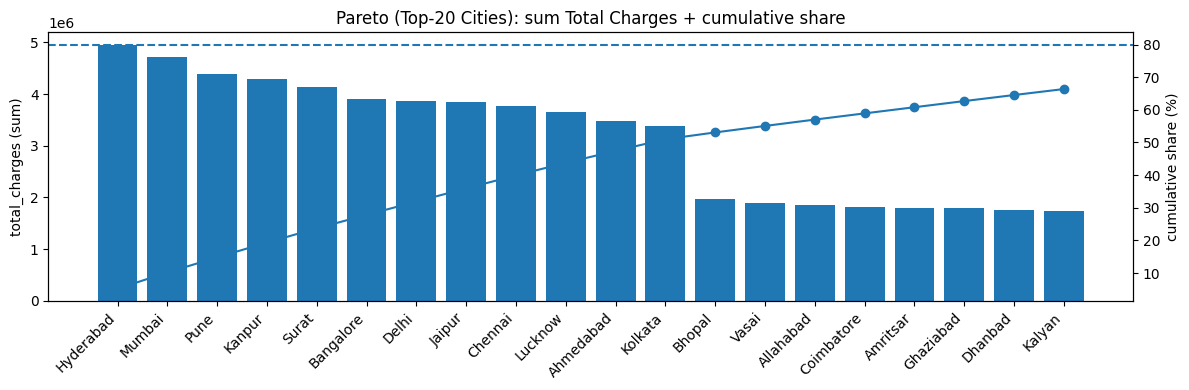

,value_sum,cum_share
city,,
Hyderabad,4947160,5.212807
Mumbai,4707754,10.173353
Pune,4396099,14.805509
Kanpur,4295398,19.331556
Surat,4142217,23.696197
Bangalore,3911721,27.817966
Delhi,3859872,31.885101
Jaipur,3846770,35.938430
Chennai,3773015,39.914044


In [ ]:
# Код побудови Pareto chart (20/80)